# Classification Experiments

Enthält:

* Baseline-Experimente
* Vergleich verschiedener Datensatzgrößen
* Binäre Klassifikation
* TF-IDF-Feature-Engineering
* Regelbasiertes Target Engineering

Das Notebook wird derzeit überarbeitet und dokumentiert.

# Classification: Feature Engineering
Emotion Intensity Prediction

## Load and Clean Review Data

In [1]:
import pandas as pd

reviews_clean = pd.read_csv(
    "../Dataset/reviews_clean.csv"
)

## Create Sample

In [132]:
classification_sample = reviews_clean.sample(
    n=50000,
    random_state=42
)
classification_sample.shape
# runtime für 1000 = 15.05 sec
# runtime für 10 000 = 2.5 min
# runtime für 50 000 = 11 min
# runtime für 100 000 = 18.13 min

(50000, 14)

## Emotion Model

In [57]:
from transformers import pipeline

classifier = pipeline(
    "text-classification",
    model="j-hartmann/emotion-english-distilroberta-base",
    top_k=None
)

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

### Measure Emotion Model Runtime

In [21]:
sample_texts = classification_sample["reviewText"]

In [22]:
import time

start = time.time()
results = sample_texts.apply(classifier)
end = time.time()

print(f"Total time: {end-start:.2f} seconds")
print(f"Time per review: {(end-start)/len(sample_texts):.4f} seconds")

Total time: 657.12 seconds
Time per review: 0.0131 seconds


### Model Control

In [23]:
#Struktur des Modellergebnisses anzeigen

# iloc = integer location
# Zugriff auf Zeilen über ihre Position im DataFrame
# iloc[0] liefert die erste Zeile bzw. den ersten Eintrag

example = classification_sample["reviewText"].iloc[0]
result = classifier(example)
result

[[{'label': 'neutral', 'score': 0.6299400329589844},
  {'label': 'joy', 'score': 0.2578708529472351},
  {'label': 'disgust', 'score': 0.06635477393865585},
  {'label': 'sadness', 'score': 0.021305464208126068},
  {'label': 'fear', 'score': 0.010636403225362301},
  {'label': 'surprise', 'score': 0.007409465499222279},
  {'label': 'anger', 'score': 0.006482984405010939}]]

In [24]:
#emotion_labels = ["anger", "disgust", "fear", "joy", "neutral", "sadness", "surprise"]

def get_emotion_scores(text):
    result = classifier(str(text))[0]
    return {item["label"]: item["score"] for item in result}

In [ ]:
get_emotion_scores(
    "This movie was absolutely fantastic. I loved every minute of it."
)

In [ ]:
get_emotion_scores(
    "This was the worst movie I have ever seen."
)

In [31]:
get_emotion_scores(
    "The movie was released in 2020 and has a runtime of two hours."
)

{'neutral': 0.7709848880767822,
 'joy': 0.14732182025909424,
 'surprise': 0.0421702042222023,
 'sadness': 0.02783505618572235,
 'anger': 0.005260132253170013,
 'disgust': 0.005187879782170057,
 'fear': 0.0012399714905768633}

In [32]:
get_emotion_scores(
    "The ending made me cry and left me feeling empty."
)

{'sadness': 0.9819384813308716,
 'neutral': 0.008232833817601204,
 'disgust': 0.0048576039262115955,
 'surprise': 0.0014785736566409469,
 'anger': 0.001356800552457571,
 'joy': 0.0010907987598329782,
 'fear': 0.00104496197309345}

In [33]:
test_texts = [
    "The movie was released in 2020 and runs for two hours.",
    "This movie was absolutely fantastic. I loved it.",
    "This was the worst movie I have ever seen.",
    "The ending made me cry.",
    "This movie was absolutely nothing special.",
    "The film tells the story of a family living in New York."
]

for text in test_texts:
    result = get_emotion_scores(text)

    print("\nTEXT:")
    print(text)

    print("\nNEUTRAL:")
    print(round(result["neutral"], 3))

    print("\nTOP EMOTION:")
    print(max(result, key=result.get))

    print("-" * 50)


TEXT:
The movie was released in 2020 and runs for two hours.

NEUTRAL:
0.543

TOP EMOTION:
neutral
--------------------------------------------------

TEXT:
This movie was absolutely fantastic. I loved it.

NEUTRAL:
0.007

TOP EMOTION:
joy
--------------------------------------------------

TEXT:
This was the worst movie I have ever seen.

NEUTRAL:
0.002

TOP EMOTION:
disgust
--------------------------------------------------

TEXT:
The ending made me cry.

NEUTRAL:
0.059

TOP EMOTION:
sadness
--------------------------------------------------

TEXT:
This movie was absolutely nothing special.

NEUTRAL:
0.462

TOP EMOTION:
neutral
--------------------------------------------------

TEXT:
The film tells the story of a family living in New York.

NEUTRAL:
0.177

TOP EMOTION:
joy
--------------------------------------------------


In [34]:
# real phrases control
sample_20 = classification_sample["reviewText"].sample(
    20,
    random_state=42
)

In [35]:
for text in sample_20:
    scores = get_emotion_scores(text)

    print(f"neutral = {scores['neutral']:.3f}")
    print(text[:200])
    print("-" * 80)

neutral = 0.005
It's said that the most of the 'horror' in classic horror films is derived from the sound effects and background score. Director John Krasinski has turned that dictum upon its head.
--------------------------------------------------------------------------------
neutral = 0.017
Nick Kozakis&#8217; tragedy of faith subjects a mentally ill heroine to her community&#8217;s blind belief
--------------------------------------------------------------------------------
neutral = 0.046
The plot is a shambles, designed not so much to tell a story as to link together a variety of scenes in which someone mutters a few choice words after being riddled with bullets and before expiring.
--------------------------------------------------------------------------------
neutral = 0.015
A gripping movie about a time when America still worked.
--------------------------------------------------------------------------------
neutral = 0.883
The story of Donald Rugoff is not just the story of

### Preliminary Evaluation of the Emotion Model
Zur ersten Überprüfung des Modells wurden mehrere Beispieltexte und zufällig ausgewählte Reviews analysiert.

Die Ergebnisse zeigen, dass das Modell emotionale Formulierungen grundsätzlich erkennt. Gleichzeitig wurden einige Einschränkungen festgestellt. Kritische Filmbewertungen, die in einem sachlichen und analytischen Stil geschrieben sind, werden häufig als „neutral“ eingestuft, obwohl sie eine negative Bewertung des Films enthalten.

Daraus schließen wir, dass das Modell eher die emotionale Ausdrucksstärke eines Textes misst als die positive oder negative Bewertung des Films.

Insgesamt erscheint das Modell für unser Projekt geeignet, da wir die emotionale Intensität von Reviews untersuchen möchten.

## Generate Emotion Scores

In [133]:
#die Emotionen für die gesamte Stichprobe.
emotion_scores = classification_sample["reviewText"].apply(get_emotion_scores)

#Frame
emotion_scores_df = pd.DataFrame(emotion_scores.tolist())

In [134]:
emotion_scores_df.columns

Index(['neutral', 'joy', 'disgust', 'sadness', 'fear', 'surprise', 'anger'], dtype='str')

In [135]:
#Concatination classification_sample mit emotions
classification_sample = pd.concat(
    [
        classification_sample.reset_index(drop=True),
        emotion_scores_df.reset_index(drop=True)
    ],
    axis=1
)
classification_sample.shape

(50000, 21)

In [108]:
classification_sample.columns.tolist()

['id',
 'reviewId',
 'creationDate',
 'criticName',
 'isTopCritic',
 'originalScore',
 'reviewState',
 'publicatioName',
 'reviewText',
 'scoreSentiment',
 'reviewUrl',
 'word_count',
 'language',
 'letter_ratio',
 'neutral',
 'joy',
 'disgust',
 'sadness',
 'fear',
 'surprise',
 'anger']

In [62]:
emotion_scores_df.columns.tolist()

['neutral', 'joy', 'disgust', 'sadness', 'fear', 'surprise', 'anger']

In [109]:
classification_sample[
    [
        "reviewText",
        "anger",
        "disgust",
        "fear",
        "joy",
        "neutral",
        "sadness",
        "surprise"
    ]
].head()

,reviewText,anger,disgust,fear,joy,neutral,sadness,surprise
0,"Worth seeing and often very droll, as well as ...",0.006483,0.066355,0.010636,0.257871,0.629940,0.021305,0.007409
1,"It's a sweet, well-intentioned film.",0.002483,0.007371,0.000440,0.917970,0.063990,0.003375,0.004370
2,"The result is a spellbinding, and breathtaking...",0.001578,0.004631,0.034202,0.905096,0.023963,0.003120,0.027411
3,Dick Johnson is Dead is both a poetic act of d...,0.283273,0.212361,0.016296,0.015207,0.441720,0.026638,0.004505
4,"A profile of the Satanic Temple, the movie fol...",0.068652,0.788241,0.052556,0.005155,0.068657,0.015125,0.001613


## Create Emotion Intensity Classes

### Emotional Intensity Score

In [136]:
# Emotional Intensity = 1 - Neutral Emotion Score
classification_sample["emotional_intensity"] = (
    1 - classification_sample["neutral"]
)

In [137]:
classification_sample["emotional_intensity"].describe()

count    50000.000000
mean         0.629009
std          0.325486
min          0.021026
25%          0.320902
50%          0.730224
75%          0.935988
max          0.999639
Name: emotional_intensity, dtype: float64

### Variant 1. Emotion Intensity Classification (Fixed Thresholds)
Low:    0.00 – 0.33
Medium: 0.34 – 0.67
High:   0.68 – 1.00

In [138]:
def classify_intensity(x):
    if x <= 0.33:
        return "low"
    elif x <= 0.67:
        return "medium"
    else:
        return "high"

classification_sample["emotion_intensity_class"] = (
    classification_sample["emotional_intensity"]
    .apply(classify_intensity)
)


### Variant 2. Balanced Emotion Intensity Classes Using Quantiles

In [139]:
classification_sample["emotion_intensity_class_q"] = pd.qcut(
    classification_sample["emotional_intensity"],
    q=3,
    labels=["low", "medium", "high"]
)

### Comparison of Both Approaches

Two approaches were used to create emotion intensity classes.

The fixed-threshold approach uses predefined intensity intervals:
- low: 0.00–0.33
- medium: 0.34–0.67
- high: 0.68–1.00

The quantile-based approach divides the dataset into three equally sized groups. This produces balanced target classes and is therefore particularly suitable for machine learning experiments.

Both target variables are retained for further analysis and model comparison.

In [140]:
classification_sample["emotion_intensity_class"].value_counts()

emotion_intensity_class
high      27142
low       12778
medium    10080
Name: count, dtype: int64

In [141]:
classification_sample["emotion_intensity_class_q"].value_counts()

emotion_intensity_class_q
low       16667
high      16667
medium    16666
Name: count, dtype: int64

In [69]:
"""
The fixed-threshold approach reflects a theoretical interpretation of emotional intensity, whereas the quantile-based approach creates balanced target classes for machine learning experiments.
"""

'\nThe fixed-threshold approach reflects a theoretical interpretation of emotional intensity, whereas the quantile-based approach creates balanced target classes for machine learning experiments.\n'

### Save Processed Classification Dataset

In [142]:
classification_sample.to_csv(
    "../Dataset/classification_sample_with_emotions.csv",
    index=False
)
print("Classification dataset saved.")

Classification dataset saved.


In [143]:
import os

size_mb = (
    os.path.getsize(
        "../Dataset/classification_sample_with_emotions.csv"
    )
    / 1024 / 1024
)

print(f"{size_mb:.2f} MB")

23.48 MB


# Classification Model

## Classification Approach

Goal:

Predict the emotional intensity class of a review
(low / medium / high)
based on the review text.

Input:
reviewText

Target:
emotion_intensity_class_q

Method:
TF-IDF Vectorization +
Logistic Regression Classifier
____________________________________
reviewText
↓
TF-IDF
↓
Logistic Regression
↓
emotion_intensity_class_q

## Load Processed Classification Dataset

In [144]:
import pandas as pd

classification_sample = pd.read_csv(
    "../Dataset/classification_sample_with_emotions.csv"
)

## Train-Test Split

In [145]:
# target
y = classification_sample["emotion_intensity_class_q"]

In [146]:
# die Klasse anhand des Textes vorhersagen
X = classification_sample["reviewText"]

In [147]:
"""
Train/Test Split
stratify=y ist wichtig: Dadurch bleibt die Verteilung der Klassen low / medium / high in Trainings- und Testdaten gleich.
"""
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [148]:
print(X_train.shape)
print(X_test.shape)

print(y_train.value_counts())
print(y_test.value_counts())

(40000,)
(10000,)
emotion_intensity_class_q
low       13334
high      13333
medium    13333
Name: count, dtype: int64
emotion_intensity_class_q
high      3334
low       3333
medium    3333
Name: count, dtype: int64


## TF-IDF Vectorization

The review texts are converted into numerical feature vectors using TF-IDF (Term Frequency–Inverse Document Frequency).

To reduce dimensionality and computational costs, only the 10,000 most informative terms are retained. Common English stop words (e.g. "the", "of", "and") are removed because they carry little information for predicting emotional intensity.
We use a custom English stop word list. Some words such as "not", "very", "never" and "interest" were removed from the default stop word list because they can be relevant for emotional intensity.

In [149]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

len(ENGLISH_STOP_WORDS)

318

In [150]:
list(ENGLISH_STOP_WORDS)[:318]

['than',
 'whether',
 'across',
 'everywhere',
 'everyone',
 'meanwhile',
 'such',
 'take',
 'otherwise',
 'only',
 'herein',
 'even',
 'onto',
 'why',
 'somewhere',
 'part',
 'at',
 'due',
 'rather',
 'them',
 'also',
 'this',
 'few',
 'without',
 'along',
 'serious',
 'wherein',
 'anyway',
 'made',
 'amount',
 'about',
 'thin',
 'ourselves',
 'very',
 'once',
 'other',
 'hundred',
 'the',
 'through',
 'hasnt',
 'already',
 'ever',
 'not',
 'whatever',
 'might',
 'yourself',
 'interest',
 'nobody',
 'twenty',
 'describe',
 'can',
 'therein',
 'name',
 'beside',
 'am',
 'are',
 'out',
 'back',
 'sometime',
 'has',
 'much',
 'should',
 'inc',
 'thereafter',
 'etc',
 'in',
 'no',
 'although',
 'upon',
 'nowhere',
 'system',
 'ie',
 'of',
 'it',
 'sixty',
 'thereby',
 'becoming',
 'couldnt',
 'above',
 'three',
 'below',
 'me',
 'under',
 'forty',
 'everything',
 'get',
 'elsewhere',
 'almost',
 'third',
 'former',
 'call',
 'all',
 'con',
 'my',
 'your',
 'before',
 'something',
 'been',

In [151]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

custom_stop_words = set(ENGLISH_STOP_WORDS) - {
    "not",
    "no",
    "never",
    "very",
    "interest",
    "serious",
    "already",
    "sincere",
    "enough",
    "none",
    "however",
    "more",
    "alone",
    "over",
    "again",
    "mostly",
    "off",
    "neither",
    "nothing",
    "down"
}

In [152]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=10000,
    stop_words=list(custom_stop_words)
)

"""
fit_transform() nur auf den Trainingsdaten:
Der Vektorizer lernt hier das Vokabular und erstellt die TF-IDF-Merkmale.
transform() auf den Testdaten:
Es wird dasselbe Vokabular verwendet, ohne Informationen aus den Testdaten zu lernen.
Dadurch vermeiden wir Data Leakage.
"""

# train
X_train_tfidf = vectorizer.fit_transform(X_train)

# test
X_test_tfidf = vectorizer.transform(X_test)

## Logistic Regression Classifier

Für die erste Klassifikationsaufgabe wurde Logistic Regression als Baseline-Modell gewählt.

Gründe für diese Wahl:
- gut geeignet für Textklassifikation in Kombination mit TF-IDF-Merkmalen,
- schnell zu trainieren und zu interpretieren,
- liefert eine solide Baseline für den Vergleich mit komplexeren Modellen,
- funktioniert auch bei einer großen Anzahl von Merkmalen zuverlässig.

Der Parameter `max_iter=1000` wurde verwendet, da die TF-IDF-Vektorisierung bis zu 10.000 Merkmale erzeugt. Eine höhere Anzahl von Iterationen hilft dem Optimierungsverfahren, zuverlässig zu konvergieren und Convergence Warnings zu vermeiden.

In [153]:
from sklearn.linear_model import LogisticRegression

In [154]:
# Logistic Regression als Baseline-Modell für die Textklassifikation
# max_iter=1000 erhöht die Anzahl der Optimierungsschritte und verhindert Convergence Warnings

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

## ML

In [155]:
model.fit(
    X_train_tfidf,
    y_train
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

### Model Training

The Logistic Regression model was successfully trained on the TF-IDF feature matrix.

The TF-IDF vectorization produced 10,000 text features. The optimization converged after 84 iterations, well below the specified maximum of 1,000 iterations. This indicates that the model was able to find a stable solution without convergence issues.

## Prediction

In [156]:
y_pred = model.predict(
    X_test_tfidf
)

## Evaluation

In [157]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        high       0.67      0.62      0.64      3334
         low       0.59      0.69      0.64      3333
      medium       0.45      0.41      0.43      3333

    accuracy                           0.57     10000
   macro avg       0.57      0.57      0.57     10000
weighted avg       0.57      0.57      0.57     10000



In [158]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

cm

array([[2064,  435,  835],
       [ 203, 2303,  827],
       [ 804, 1179, 1350]])

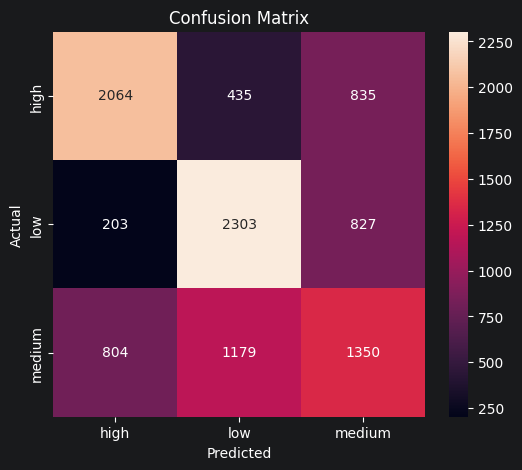

In [159]:
# Visualisierung für Erste Ergebnisse
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Results

### First Classification Results

The baseline Logistic Regression classifier achieved an overall accuracy of 57%.

The model performed best on the high and low intensity classes, reaching F1-scores of 0.64 and 0.63 respectively.

The medium intensity class was more difficult to classify (F1-score = 0.42), likely because reviews with moderate emotional intensity share characteristics with both low- and high-intensity reviews.

Overall, the results indicate that emotional intensity can be predicted from review text better than random guessing, while leaving room for further model improvements.


In [160]:
results = pd.DataFrame({
    "reviewText": X_test,
    "actual": y_test,
    "predicted": y_pred
})

results.to_csv(
    "../Dataset/classification_predictions.csv",
    index=False
)

# Model Improvement Experiments

## Experiment 1
Logistic Regression
100 000 Reviews

### 100k Reviews

In [161]:
classification_sample_100k = reviews_clean.sample(
    n=100000,
    random_state=42
)
classification_sample_100k.shape
# runtime für 100 000 = 18.13 min

(100000, 14)

In [162]:
#die Emotionen für die gesamte Stichprobe.
emotion_scores_100k = classification_sample_100k["reviewText"].apply(get_emotion_scores)

#Frame
emotion_scores_100k_df = pd.DataFrame(emotion_scores_100k.tolist())

In [163]:
#Concatination classification_sample_100k mit emotions
classification_sample_100k = pd.concat(
    [
        classification_sample_100k.reset_index(drop=True),
        emotion_scores_100k_df.reset_index(drop=True)
    ],
    axis=1
)
classification_sample_100k.shape

(100000, 21)

In [164]:
# Emotional Intensity = 1 - Neutral Emotion Score
classification_sample_100k["emotional_intensity"] = (
        1 - classification_sample_100k["neutral"]
)

In [165]:
classification_sample_100k["emotion_intensity_class_q"] = pd.qcut(
    classification_sample_100k["emotional_intensity"],
    q=3,
    labels=["low", "medium", "high"]
)

In [166]:
classification_sample_100k.to_csv(
    "../Dataset/classification_sample_100k_with_emotions.csv",
    index=False
)
print("Classification dataset für 100k saved.")

Classification dataset für 100k saved.


### Logistic Regression für 100k

In [374]:
classification_sample_100k = pd.read_csv(
    "../Dataset/classification_sample_100k_with_emotions.csv"
)

In [168]:
# target
y_100k = classification_sample_100k["emotion_intensity_class_q"]
# die Klasse anhand des Textes vorhersagen
X_100k = classification_sample_100k["reviewText"]
"""
Train/Test Split
stratify=y ist wichtig: Dadurch bleibt die Verteilung der Klassen low / medium / high in Trainings- und Testdaten gleich.
"""


X_train_100k, X_test_100k, y_train_100k, y_test_100k = train_test_split(
    X_100k,
    y_100k,
    test_size=0.2,
    random_state=42,
    stratify=y_100k
)
print(X_train_100k.shape)
print(X_test_100k.shape)

print(y_train_100k.value_counts())
print(y_test_100k.value_counts())

(80000,)
(20000,)
emotion_intensity_class_q
medium    26667
low       26667
high      26666
Name: count, dtype: int64
emotion_intensity_class_q
low       6667
high      6667
medium    6666
Name: count, dtype: int64


In [169]:
"""
fit_transform() nur auf den Trainingsdaten:
Der Vektorizer lernt hier das Vokabular und erstellt die TF-IDF-Merkmale.
transform() auf den Testdaten:
Es wird dasselbe Vokabular verwendet, ohne Informationen aus den Testdaten zu lernen.
Dadurch vermeiden wir Data Leakage.
"""

# train
X_train_100k_tfidf = vectorizer.fit_transform(X_train_100k)

# test
X_test_100k_tfidf = vectorizer.transform(X_test_100k)

In [170]:
# Logistic Regression als Baseline-Modell für die Textklassifikation
# max_iter=1000 erhöht die Anzahl der Optimierungsschritte und verhindert Convergence Warnings

model_100k = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [171]:
model_100k.fit(
    X_train_100k_tfidf,
    y_train_100k
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [ ]:
y_pred_100k = model_100k.predict(
    X_test_100k_tfidf
)

### Evaluation 100k

In [172]:
print(classification_report(y_test_100k, y_pred_100k))

              precision    recall  f1-score   support

        high       0.68      0.63      0.65      6667
         low       0.60      0.71      0.65      6667
      medium       0.46      0.41      0.44      6666

    accuracy                           0.58     20000
   macro avg       0.58      0.58      0.58     20000
weighted avg       0.58      0.58      0.58     20000



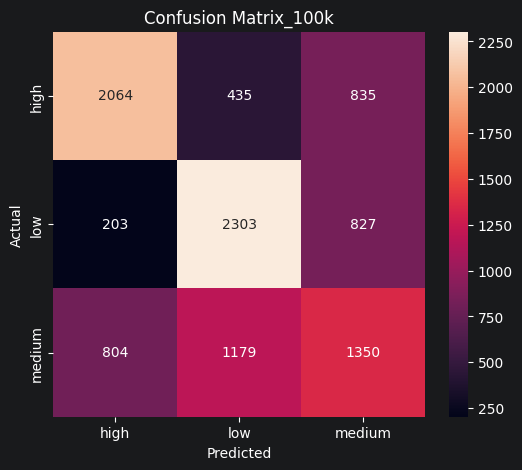

In [173]:
# Visualisierung für Experiment 1

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=model_100k.classes_,
    yticklabels=model_100k.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix_100k")
plt.show()

In [174]:
results = pd.DataFrame({
    "reviewText": X_test_100k,
    "actual": y_test_100k,
    "predicted": y_pred_100k
})

results.to_csv(
    "../Dataset/classification_predictions_100k.csv",
    index=False
)

### Second Classification Results

Die Vergrößerung der Stichprobe von 50.000 auf 100.000 Reviews führte nur zu einer geringen Verbesserung der Accuracy (57 % → 58 %). Dies deutet darauf hin, dass die Hauptschwierigkeit nicht in der Datenmenge liegt, sondern in der Abgrenzung der Klasse „medium“, die deutlich schwieriger zu klassifizieren ist als „low“ und „high“.

### Analysis of results

In [176]:
# Logistic Regression.Top Words
feature_names = vectorizer.get_feature_names_out()
len(feature_names)

10000

In [177]:
model.classes_

array(['high', 'low', 'medium'], dtype=object)

In [178]:
# HIGH
high_idx = list(model.classes_).index("high")

high_words = pd.DataFrame({
    "word": feature_names,
    "coef": model.coef_[high_idx]
})

high_words.sort_values(
    "coef",
    ascending=False
).head(20)

,word,coef
4337,houston,7.118377
8745,susan,5.345071
9916,worship,5.332154
2957,en,5.286585
756,balloon,4.905933
7622,russia,4.865457
2932,emerging,4.801017
9914,worrying,4.760789
7617,runtime,4.638433
3681,frightening,4.579194


In [ ]:
"""
Die Analyse der wichtigsten TF-IDF-Merkmale zeigte, dass die Klassifikation nicht ausschließlich auf emotionalen Wörtern basiert. Neben emotional geprägten Begriffen wie frightening, harrowing oder worrying wurden auch thematische Wörter und Eigennamen als wichtige Merkmale identifiziert. Dies verdeutlicht eine typische Eigenschaft von TF-IDF-basierten Modellen: Sie lernen statistische Zusammenhänge zwischen Wörtern und Klassen, ohne deren semantische Bedeutung zu verstehen.
"""

In [179]:
# LOW
low_idx = list(model.classes_).index("low")

low_words = pd.DataFrame({
    "word": feature_names,
    "coef": model.coef_[low_idx]
})

low_words.sort_values(
    "coef",
    ascending=False
).head(20)

,word,coef
911,bite,1.738724
748,balance,1.588672
5991,necessary,1.546085
7739,schrader,1.504832
4960,kenneth,1.450475
7399,responsibility,1.445257
2405,desires,1.432756
5749,miscast,1.420059
9379,uneasy,1.413104
1947,cook,1.404040


In [180]:
# MEDIUM
medium_idx = list(model.classes_).index("medium")

medium_words = pd.DataFrame({
    "word": feature_names,
    "coef": model.coef_[medium_idx]
})

medium_words.sort_values(
    "coef",
    ascending=False
).head(20)

,word,coef
3692,frustrating,1.746694
8604,stylised,1.694140
9414,uninvolving,1.657492
8671,suggests,1.616099
1654,coda,1.603432
3564,fond,1.522001
6470,pearce,1.489143
8936,terror,1.447506
4512,impulse,1.404328
3248,extension,1.395445


### Evaluation_Additional
Die Analyse der wichtigsten TF-IDF-Merkmale zeigte einen klaren Unterschied zwischen den Klassen mit niedriger und hoher Emotionsintensität.

Die mittlere Klasse war dagegen weniger eindeutig. Sie enthielt eine Mischung aus positiven, negativen und neutralen Begriffen. Das deutet darauf hin, dass diese Klasse eher einen Übergangsbereich darstellt als eine klar abgrenzbare Kategorie.

Dies erklärt auch, warum die mittlere Klasse schwieriger zu klassifizieren ist und einen niedrigeren F1-Score erzielt hat als die Klassen mit niedriger oder hoher Intensität.

## Experiment 2
Fixed Threshold Intensity Classes

### Create Emotion Intensity Classes

In [185]:
"""
def classify_intensity(x):
    if x <= 0.33:
        return "low"
    elif x <= 0.67:
        return "medium"
    else:
        return "high"
"""

classification_sample_100k["emotion_intensity_class"] = (
    classification_sample_100k["emotional_intensity"]
    .apply(classify_intensity)
)


In [186]:
classification_sample_100k["emotion_intensity_class"].value_counts()

emotion_intensity_class
high      54326
low       25483
medium    20191
Name: count, dtype: int64

### ML pipeline

In [187]:
X_fixed = classification_sample_100k["reviewText"]
y_fixed = classification_sample_100k["emotion_intensity_class"]

X_train_fixed, X_test_fixed, y_train_fixed, y_test_fixed = train_test_split(
    X_fixed,
    y_fixed,
    test_size=0.2,
    random_state=42,
    stratify=y_fixed
)

In [188]:
X_train_fixed_tfidf = vectorizer.fit_transform(X_train_fixed)
X_test_fixed_tfidf = vectorizer.transform(X_test_fixed)

In [189]:
model_fixed = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model_fixed.fit(X_train_fixed_tfidf, y_train_fixed)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [190]:
y_pred_fixed = model_fixed.predict(X_test_fixed_tfidf)

print(classification_report(y_test_fixed, y_pred_fixed))

              precision    recall  f1-score   support

        high       0.71      0.86      0.78     10865
         low       0.57      0.61      0.59      5097
      medium       0.33      0.11      0.16      4038

    accuracy                           0.64     20000
   macro avg       0.53      0.52      0.51     20000
weighted avg       0.59      0.64      0.60     20000



### Evaluation. Feste Schwellenwerte

Zwei Ansätze zur Definition der Zielvariable wurden untersucht: feste Schwellenwerte und Quantile.
Obwohl feste Schwellenwerte eine höhere Accuracy erzielten (64 %), führte die starke Klassenungleichheit zu einer deutlich schlechteren Erkennung der Klasse “medium”.

Daher wurden Quantile als Zielvariable bevorzugt, da sie ausgeglichenere Klassen erzeugen und insgesamt robustere Ergebnisse liefern.

## Experiment 3
Binary Classification: Low vs High
"extreme groups approach"

Die Idee besteht darin, die problematischste Übergangsklasse „medium“ zu entfernen und zu testen, wie gut das Modell nur zwischen „low“ und „high“ unterscheiden kann.

### Binary Sample

In [191]:
# Keep only low and high classes
binary_sample = classification_sample_100k[
    classification_sample_100k["emotion_intensity_class_q"].isin(["low", "high"])
].copy()

In [192]:
binary_sample["emotion_intensity_class_q"].value_counts()

emotion_intensity_class_q
low     33334
high    33333
Name: count, dtype: int64

### ML Pipeline

In [193]:
X_binary = binary_sample["reviewText"]
y_binary = binary_sample["emotion_intensity_class_q"]

In [194]:
X_train_binary, X_test_binary, y_train_binary, y_test_binary = train_test_split(
    X_binary,
    y_binary,
    test_size=0.2,
    random_state=42,
    stratify=y_binary
)

In [195]:
#TF-IDF
X_train_binary_tfidf = vectorizer.fit_transform(X_train_binary)
X_test_binary_tfidf = vectorizer.transform(X_test_binary)

In [196]:
#Model
model_binary = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model_binary.fit(X_train_binary_tfidf, y_train_binary)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [197]:
#Prediction + Evaluation
y_pred_binary = model_binary.predict(X_test_binary_tfidf)

print(classification_report(y_test_binary, y_pred_binary))

              precision    recall  f1-score   support

        high       0.87      0.77      0.82      6667
         low       0.80      0.89      0.84      6667

    accuracy                           0.83     13334
   macro avg       0.83      0.83      0.83     13334
weighted avg       0.83      0.83      0.83     13334



### Evaluation. Extreme Groups

Die Ergebnisse des Extreme-Groups-Ansatzes zeigen, dass Reviews mit niedriger und hoher emotionaler Intensität sehr gut voneinander unterschieden werden können (Accuracy = 83 %).

Die deutlich schwächere Leistung des Drei-Klassen-Modells scheint daher hauptsächlich auf die Klasse „medium“ zurückzuführen zu sein, die eher eine Übergangszone zwischen niedriger und hoher emotionaler Intensität darstellt.

## Experiment 4
Cleaner TF-IDF Features

Die Idee besteht darin, Störmerkmale aus TF-IDF zu entfernen, die nicht direkt die Emotionalität widerspiegeln.

### Exclamation marks

Rezensionen mit hoher emotionaler Intensität enthielten etwa dreimal häufiger Ausrufezeichen als solche mit geringer emotionaler Intensität. Die Gesamthäufigkeit von Ausrufezeichen war jedoch sehr gering (< 2 % der Rezensionen), was ihren Nutzen als prädiktives Merkmal einschränkte.

In [199]:
classification_sample["exclamation_count"] = (
    classification_sample["reviewText"]
    .str.count("!")
)

In [200]:
classification_sample.groupby(
    "emotion_intensity_class_q"
)["exclamation_count"].mean()

emotion_intensity_class_q
high      0.019560
low       0.005760
medium    0.012721
Name: exclamation_count, dtype: float64

In [201]:
classification_sample["has_exclamation"] = (
    classification_sample["exclamation_count"] > 0
).astype(int)

In [202]:
classification_sample.groupby(
    "emotion_intensity_class_q"
)["has_exclamation"].mean()

emotion_intensity_class_q
high      0.0156
low       0.0051
medium    0.0114
Name: has_exclamation, dtype: float64

### Word Count

Interpretation der Wortanzahl

Die Analyse zeigte nur sehr geringe Unterschiede in der durchschnittlichen Länge der Rezensionen zwischen den Intensitätsklassen.

| Klasse | Durchschnittliche Wortanzahl |
|---------|----------------------------|
| Low | 22.80 |
| Medium | 22.31 |
| High | 21.51 |

Entgegen der ursprünglichen Annahme sind emotional intensivere Rezensionen nicht länger als weniger emotionale Rezensionen.

Dies deutet darauf hin, dass emotionale Intensität hauptsächlich durch die Wortwahl und nicht durch die Länge einer Rezension ausgedrückt wird. Die Wortanzahl scheint daher kein geeignetes Merkmal zur Verbesserung der Klassifikation zu sein.

In [203]:
classification_sample.groupby(
    "emotion_intensity_class_q"
)["word_count"].mean()

emotion_intensity_class_q
high      21.509390
low       22.803924
medium    22.309312
Name: word_count, dtype: float64

### New Vectorizer

In [205]:
vectorizer_clean = TfidfVectorizer(
    max_features=10000,
    stop_words=list(custom_stop_words),
    token_pattern=r"(?u)\b[a-zA-Z]{3,}\b",
    min_df=5
)

### ML Pipeline

100k reviews |
emotion_intensity_class_q |
3 classes |
quantile approach

In [206]:
# train
X_train_100k_tfidf_clean = (
    vectorizer_clean.fit_transform(X_train_100k)
)

# test
X_test_100k_tfidf_clean = (
    vectorizer_clean.transform(X_test_100k)
)

In [207]:
model_clean = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model_clean.fit(
    X_train_100k_tfidf_clean,
    y_train_100k
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [208]:
y_pred_clean = model_clean.predict(
    X_test_100k_tfidf_clean
)

print(
    classification_report(
        y_test_100k,
        y_pred_clean
    )
)

              precision    recall  f1-score   support

        high       0.66      0.61      0.64      6667
         low       0.59      0.70      0.64      6667
      medium       0.45      0.41      0.43      6666

    accuracy                           0.57     20000
   macro avg       0.57      0.57      0.57     20000
weighted avg       0.57      0.57      0.57     20000



### Evaluation of Cleaner TF-IDF Features

In diesem Experiment wurde die TF-IDF-Darstellung bereinigt, indem numerische Tokens, sehr kurze Tokens und seltene Wörter entfernt wurden.

Die Modellleistung blieb jedoch nahezu unverändert:

| Modell | Accuracy | Macro F1 |
|---------|----------|----------|
| Baseline (100k) | 0.58 | 0.58 |
| Cleaner TF-IDF | 0.57 | 0.57 |

Die Ergebnisse zeigen, dass seltene oder potenziell störende Wörter nicht die Hauptursache für die Fehlklassifikationen sind. Die Bereinigung der Merkmale führte zu keiner Verbesserung der Modellleistung.

Dies deutet darauf hin, dass die größte Herausforderung weiterhin in der Trennung der Klasse „medium“ liegt, die sprachlich weniger klar von den Klassen „low“ und „high“ abgegrenzt werden kann.

Feature Cleaning allein reicht daher nicht aus, um die Klassifikation deutlich zu verbessern.

## Experiment 5
TF-IDF with Bigrams

nicht nur: boring, funny, moving, recommend

sondern auch: very boring, not funny, deeply moving, highly recommend

### New Vectorizer

In [262]:
"""
TF-IDF mit Unigrammen und Bigrammen.

Zusätzlich zu einzelnen Wörtern (Unigramme) werden nun auch
Wortpaare (Bigramme) berücksichtigt.

Dadurch kann das Modell Ausdrücke wie
'not funny', 'very boring' oder 'highly recommend'
als eigene Merkmale erfassen.

Die Hypothese lautet, dass emotionale Intensität häufig durch
Wortkombinationen und nicht nur durch einzelne Wörter ausgedrückt wird.
"""

vectorizer_bigram = TfidfVectorizer(
    max_features=10000,
    stop_words=list(custom_stop_words),
    ngram_range=(1, 2)

)


### ML Pipeline

In [263]:
X_train_100k_tfidf_bigram = (
    vectorizer_bigram.fit_transform(X_train_100k)
)

X_test_100k_tfidf_bigram = (
    vectorizer_bigram.transform(X_test_100k)
)

In [264]:
model_bigram = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model_bigram.fit(
    X_train_100k_tfidf_bigram,
    y_train_100k
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

### Evaluation

In [265]:
y_pred_bigram = model_bigram.predict(
    X_test_100k_tfidf_bigram
)

print(
    classification_report(
        y_test_100k,
        y_pred_bigram
    )
)

              precision    recall  f1-score   support

        high       0.68      0.63      0.65      6667
         low       0.60      0.70      0.65      6667
      medium       0.46      0.41      0.44      6666

    accuracy                           0.58     20000
   macro avg       0.58      0.58      0.58     20000
weighted avg       0.58      0.58      0.58     20000



### Analyse

In [266]:
feature_names_bigram = vectorizer_bigram.get_feature_names_out()

len(feature_names_bigram)

10000

In [267]:
bigrams = [
    feature
    for feature in feature_names_bigram
    if " " in feature
]

len(bigrams)

1902

In [268]:
bigrams[:50]

['10 10',
 '10 minutes',
 '100 minutes',
 '15 minutes',
 '15 years',
 '19th century',
 '20 minutes',
 '20 years',
 '20th century',
 '21st century',
 '30 minutes',
 '30 years',
 '41 44',
 '44 44',
 '44 8217',
 '44 8220',
 '44 apos',
 '44 does',
 '44 especially',
 '44 film',
 '44 just',
 '44 more',
 '44 movie',
 '44 never',
 '44 no',
 '44 not',
 '44 quot',
 '44 story',
 '45 minutes',
 '46 10',
 '46 44',
 '46 46',
 '46 8217',
 '46 91',
 '46 apos',
 '46 film',
 '46 movie',
 '46 quot',
 '80 minutes',
 '8217 film',
 '8217 just',
 '8217 ll',
 '8217 not',
 '8217 ve',
 '90 minute',
 '90 minutes',
 '91 93',
 '91 review',
 'aaron sorkin',
 'absolutely no']

In [269]:
coef_high = model_bigram.coef_[0]

top_high = pd.DataFrame({
    "feature": feature_names_bigram,
    "coef": coef_high
})

top_high = top_high[
    top_high["feature"].str.contains(" ")
]

top_high.sort_values(
    "coef",
    ascending=False
).head(20)

,feature,coef
5322,lot fun,2.149804
4095,hard believe,1.719914
5772,missed opportunity,1.680928
8222,smile face,1.621987
4862,just bad,1.615129
3254,feel good,1.609271
4317,horror film,1.500353
2884,entertaining film,1.449634
3897,good time,1.431441
3699,funny film,1.409273


In [270]:
coef_medium = model_bigram.coef_[1]
top_medium = pd.DataFrame({
    "feature": feature_names_bigram,
    "coef": coef_medium
})

top_medium = top_medium[
    top_medium["feature"].str.contains(" ")
]

top_medium.sort_values(
    "coef",
    ascending=False
).head(20)

,feature,coef
3554,food thought,1.435485
6229,not film,1.323033
9857,wonder woman,1.272845
6182,no wonder,1.212280
879,better off,1.208470
7909,sense word,1.163292
5470,makes work,1.160869
4869,just fine,1.141992
9525,very little,1.129184
8201,slow paced,1.103725


In [271]:
coef_low = model_bigram.coef_[2]
top_low = pd.DataFrame({
    "feature": feature_names_bigram,
    "coef": coef_low
})

top_low = top_low[
    top_low["feature"].str.contains(" ")
]

top_low.sort_values(
    "coef",
    ascending=False
).head(20)

,feature,coef
105,46 46,1.608230
4315,horror comedy,1.225342
7963,sex drugs,1.193579
851,best film,1.150134
3449,films recent,1.133335
3396,film offers,1.092800
716,bad guys,1.091547
5934,movie ll,1.073354
8722,superhero film,1.042566
5809,moments film,1.005416


#### Analysis of Important Bigrams

Die wichtigsten Bigrams zeigen deutliche Unterschiede zwischen den Klassen.

Die Klasse mit hoher Emotionsintensität enthält stark emotionale Ausdrücke wie „lot fun“, „feel good“ und „very funny“.

Die mittlere Klasse enthält dagegen eher neutrale oder gemischte Ausdrücke wie „just fine“, „needs more“ und „gets right“. Diese Formulierungen drücken häufig keine starke Emotion aus, sondern eine ausgewogene Bewertung.

Dies deutet darauf hin, dass die mittlere Klasse kein eigenes, klar erkennbares Vokabular besitzt. Stattdessen bildet sie einen Übergangsbereich zwischen niedriger und hoher Emotionsintensität.

Diese Beobachtung stimmt mit den vorherigen Experimenten überein. Nachdem die mittlere Klasse entfernt wurde, verbesserte sich die Klassifikationsleistung deutlich (Accuracy = 83 %).

## Experiment 6
Dominant Emotion Based Intensity Classes

In [272]:
emotion_cols = [
    "joy",
    "anger",
    "sadness",
    "fear",
    "surprise",
    "disgust"
]

### Dominant Emotion Model 1

In [273]:
classification_sample_100k["dominant_emotion"] = (
    classification_sample_100k[emotion_cols]
    .idxmax(axis=1)
)

classification_sample_100k["dominant_emotion_score"] = (
    classification_sample_100k[emotion_cols]
    .max(axis=1)
)

In [274]:
classification_sample_100k["non_neutral_sum"] = (
    classification_sample_100k[emotion_cols]
    .sum(axis=1)
)

#### Emotion Class

In [280]:
def classify_dominant_intensity(row):
    if row["dominant_emotion_score"] < 0.30:
        return "low"
    elif row["non_neutral_sum"] < 0.90:
        return "medium"
    else:
        return "high"

In [281]:
classification_sample_100k["emotion_intensity_class_dom"] = (
    classification_sample_100k.apply(
        classify_dominant_intensity,
        axis=1
    )
)

In [282]:
classification_sample_100k["emotion_intensity_class_dom"].value_counts()

emotion_intensity_class_dom
low       50823
high      30332
medium    18845
Name: count, dtype: int64

#### Model Analysis

In [283]:
classification_sample_100k["dominant_emotion_score"].describe()

count    100000.000000
mean          0.496573
std           0.322886
min           0.005016
25%           0.186948
50%           0.490123
75%           0.810053
max           0.994943
Name: dominant_emotion_score, dtype: float64

In [284]:
classification_sample_100k["non_neutral_sum"].describe()

count    100000.000000
mean          0.629539
std           0.324702
min           0.021026
25%           0.322134
50%           0.730491
75%           0.935753
max           0.999661
Name: non_neutral_sum, dtype: float64

In [285]:
classification_sample_100k[
    [
        "dominant_emotion_score",
        "non_neutral_sum"
    ]
].corr()

,dominant_emotion_score,non_neutral_sum
dominant_emotion_score,1.000000,0.929862
non_neutral_sum,0.929862,1.000000


### Dominant Emotion Model 2

In [286]:
classification_sample_100k["emotion_mean"] = (
    classification_sample_100k[emotion_cols]
    .mean(axis=1)
)

In [287]:
classification_sample_100k["dominance_ratio"] = (
    classification_sample_100k["dominant_emotion_score"]
    /
    classification_sample_100k["emotion_mean"]
)

In [288]:
classification_sample_100k["dominance_ratio"].describe()

count    100000.000000
mean          4.291710
std           1.273051
min           1.151089
25%           3.189927
50%           4.464193
75%           5.513879
max           5.973536
Name: dominance_ratio, dtype: float64

In [289]:
classification_sample_100k.groupby(
    "emotion_intensity_class_q"
)["dominance_ratio"].mean()

emotion_intensity_class_q
high      5.221335
low       3.262143
medium    4.391683
Name: dominance_ratio, dtype: float64

In [290]:
classification_sample_100k[
    [
        "dominance_ratio",
        "emotional_intensity"
    ]
].corr()

,dominance_ratio,emotional_intensity
dominance_ratio,1.000000,0.671663
emotional_intensity,0.671663,1.000000


### Dominance-Based Classes_Model 2

In [292]:
classification_sample_100k["dominance_class"] = pd.qcut(
    classification_sample_100k["dominance_ratio"],
    q=3,
    labels=["low", "medium", "high"]
)

### ML pipeline

In [293]:
# target
y_dom = classification_sample_100k["dominance_class"]

# die Klasse anhand des Textes vorhersagen
X_dom = classification_sample_100k["reviewText"]
"""
Train/Test Split
stratify=y ist wichtig: Dadurch bleibt die Verteilung der Klassen low / medium / high in Trainings- und Testdaten gleich.
"""


X_train_dom, X_test_dom, y_train_dom, y_test_dom = train_test_split(
    X_dom,
    y_dom,
    test_size=0.2,
    random_state=42,
    stratify=y_dom
)
print(X_train_dom.shape)
print(X_test_dom.shape)

print(y_train_dom.value_counts())
print(y_test_dom.value_counts())

(80000,)
(20000,)
dominance_class
low       26667
medium    26667
high      26666
Name: count, dtype: int64
dominance_class
low       6667
high      6667
medium    6666
Name: count, dtype: int64


In [294]:
vectorizer_dom = TfidfVectorizer(
    max_features=10000,
    stop_words=list(custom_stop_words)
)

X_train_dom_tfidf = vectorizer_dom.fit_transform(X_train_dom)
X_test_dom_tfidf = vectorizer_dom.transform(X_test_dom)

In [295]:
# train
X_train_dom_tfidf = vectorizer_dom.fit_transform(X_train_dom)

# test
X_test_dom_tfidf = vectorizer_dom.transform(X_test_dom)

In [296]:
model_dom = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [297]:
model_dom.fit(
    X_train_dom_tfidf,
    y_train_dom
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [298]:
y_pred_dom = model_dom.predict(
    X_test_dom_tfidf
)

In [299]:
print(classification_report(y_test_dom, y_pred_dom))

              precision    recall  f1-score   support

        high       0.61      0.59      0.60      6667
         low       0.49      0.54      0.51      6667
      medium       0.39      0.36      0.38      6666

    accuracy                           0.50     20000
   macro avg       0.49      0.50      0.49     20000
weighted avg       0.49      0.50      0.49     20000



### Analysis

In [300]:
classification_sample_100k[
    [
        "emotional_intensity",
        "dominance_ratio"
    ]
].describe()

,emotional_intensity,dominance_ratio
count,100000.000000,100000.000000
mean,0.629539,4.291710
std,0.324702,1.273051
min,0.021026,1.151089
25%,0.322134,3.189927
50%,0.730491,4.464193
75%,0.935753,5.513879
max,0.999661,5.973536


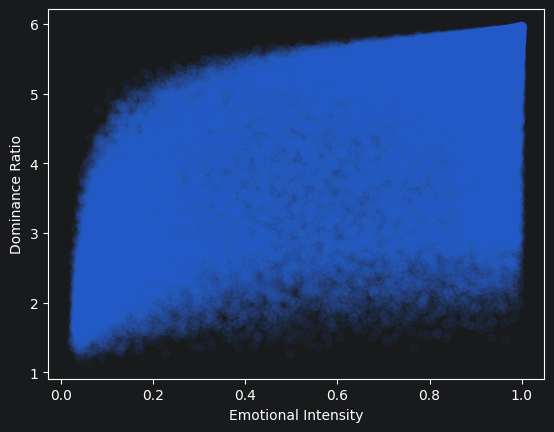

In [301]:
import matplotlib.pyplot as plt

plt.scatter(
    classification_sample_100k["emotional_intensity"],
    classification_sample_100k["dominance_ratio"],
    alpha=0.05
)

plt.xlabel("Emotional Intensity")
plt.ylabel("Dominance Ratio")
plt.show()

In [302]:
classification_sample_100k["intensity_z"] = (
    (classification_sample_100k["emotional_intensity"]
     - classification_sample_100k["emotional_intensity"].mean())
    /
    classification_sample_100k["emotional_intensity"].std()
)

classification_sample_100k["dominance_z"] = (
    (classification_sample_100k["dominance_ratio"]
     - classification_sample_100k["dominance_ratio"].mean())
    /
    classification_sample_100k["dominance_ratio"].std()
)

In [303]:
classification_sample_100k["emotion_strength"] = (
    classification_sample_100k["intensity_z"]
    +
    classification_sample_100k["dominance_z"]
)

In [304]:
classification_sample_100k["emotion_strength_class"] = pd.qcut(
    classification_sample_100k["emotion_strength"],
    q=3,
    labels=["low", "medium", "high"]
)

In [306]:
classification_sample_100k[
    [
        "emotion_strength",
        "emotional_intensity",
        "dominance_ratio"
    ]
].corr()

,emotion_strength,emotional_intensity,dominance_ratio
emotion_strength,1.000000,0.914238,0.914238
emotional_intensity,0.914238,1.000000,0.671663
dominance_ratio,0.914238,0.671663,1.000000


## Experiment 7
Emotion Gap
Gap = strongest emotion - second strongest emotion


In [313]:
import numpy as np

In [314]:
emotion_cols = [
    "joy",
    "anger",
    "sadness",
    "fear",
    "surprise",
    "disgust"
]

emotion_values = classification_sample_100k[
    emotion_cols
].values

sorted_emotions = np.sort(
    emotion_values,
    axis=1
)

classification_sample_100k["emotion_gap"] = (
    sorted_emotions[:, -1]
    - sorted_emotions[:, -2]
)

In [315]:
classification_sample_100k["emotion_gap"].describe()

count    1.000000e+05
mean     4.176277e-01
std      3.418264e-01
min      2.682209e-07
25%      8.164134e-02
50%      3.486685e-01
75%      7.575760e-01
max      9.937512e-01
Name: emotion_gap, dtype: float64

In [316]:
classification_sample_100k.groupby(
    "emotion_intensity_class_q"
)["emotion_gap"].mean()

emotion_intensity_class_q
high      0.753705
low       0.084443
medium    0.414745
Name: emotion_gap, dtype: float64

In [317]:
classification_sample_100k[
    [
        "emotion_gap",
        "emotional_intensity"
    ]
].corr()

,emotion_gap,emotional_intensity
emotion_gap,1.000000,0.814769
emotional_intensity,0.814769,1.000000


In [319]:
# Number of active emotions
def count_active_emotions(row):

    return sum(
        row[col] >= 0.10
        for col in emotion_cols
    )

classification_sample_100k["active_emotions"] = (
    classification_sample_100k.apply(
        count_active_emotions,
        axis=1
    )
)

### Analysis
High-intensity reviews are not only less neutral, but also characterized by a clear dominance of one emotion over competing emotional signals.

In [320]:
classification_sample_100k["active_emotions"].value_counts()

active_emotions
1    56854
2    22430
0    15979
3     4352
4      371
5       14
Name: count, dtype: int64

In [321]:
classification_sample_100k.groupby(
    "emotion_intensity_class_q"
)["active_emotions"].mean()

emotion_intensity_class_q
high      1.327423
low       0.607128
medium    1.555186
Name: active_emotions, dtype: float64

In [322]:
# Dominant emotions
classification_sample_100k["dominant_emotion"].value_counts(
    normalize=True
)

dominant_emotion
joy         0.40729
disgust     0.24143
sadness     0.10738
surprise    0.10226
fear        0.10129
anger       0.04035
Name: proportion, dtype: float64

In [323]:
pd.crosstab(
    classification_sample_100k["emotion_intensity_class_q"],
    classification_sample_100k["dominant_emotion"],
    normalize="index"
)

dominant_emotion,anger,disgust,fear,joy,sadness,surprise
emotion_intensity_class_q,,,,,,
high,0.050431,0.197162,0.177272,0.389614,0.129481,0.056041
low,0.029189,0.295794,0.040979,0.386182,0.075268,0.172587
medium,0.041430,0.231332,0.085621,0.446074,0.117391,0.078151


In [324]:
pd.crosstab(
    classification_sample_100k["emotion_intensity_class_q"],
    classification_sample_100k["active_emotions"],
    normalize="index"
)

active_emotions,0,1,2,3,4,5
emotion_intensity_class_q,,,,,,
high,0.00000,0.728827,0.219662,0.046980,0.00432,0.00021
low,0.47936,0.436611,0.081568,0.002460,0.00000,0.00000
medium,0.00000,0.540185,0.371674,0.081121,0.00681,0.00021


### Analysis of Emotional Structure

Die zusätzlichen Analysen zeigten klare Unterschiede zwischen den drei Intensitätsklassen.

Fast die Hälfte der Reviews mit niedriger Intensität (47,9 %) enthielt keine Emotion, die den festgelegten Schwellenwert überschritt.

Bei den Reviews mit hoher Intensität war meist eine Emotion klar dominant. In 72,9 % der Fälle gab es genau eine aktive Emotion.

Die mittlere Klasse zeigte ein anderes Bild. Hier traten häufiger mehrere Emotionen gleichzeitig auf. Mehr als ein Drittel der Reviews enthielt zwei aktive Emotionen, und fast 9 % sogar drei oder mehr.

Diese Ergebnisse deuten darauf hin, dass die mittlere Klasse oft gemischte oder weniger eindeutige emotionale Inhalte enthält. Die hohe Intensitätsklasse ist dagegen meist durch eine klar erkennbare dominante Emotion gekennzeichnet.

In [326]:
classification_sample_100k[
    [
        "emotion_gap",
        "active_emotions"
    ]
].corr()

,emotion_gap,active_emotions
emotion_gap,1.000000,0.037472
active_emotions,0.037472,1.000000


### Emotion Structure Score

In [328]:
# Normalisation
classification_sample_100k["gap_z"] = (
    classification_sample_100k["emotion_gap"]
    - classification_sample_100k["emotion_gap"].mean()
) / classification_sample_100k["emotion_gap"].std()

classification_sample_100k["active_z"] = (
    classification_sample_100k["active_emotions"]
    - classification_sample_100k["active_emotions"].mean()
) / classification_sample_100k["active_emotions"].std()

In [329]:
classification_sample_100k["emotion_structure_score"] = (
    classification_sample_100k["gap_z"]
    +
    classification_sample_100k["active_z"]
)

In [330]:
classification_sample_100k["emotion_structure_class"] = pd.qcut(
    classification_sample_100k["emotion_structure_score"],
    q=3,
    labels=["low", "medium", "high"]
)

In [331]:
classification_sample_100k[
    [
        "emotion_structure_score",
        "emotional_intensity"
    ]
].corr()

,emotion_structure_score,emotional_intensity
emotion_structure_score,1.000000,0.926296
emotional_intensity,0.926296,1.000000


### ML pipeline

In [334]:
# Target based on emotion structure score
y_structure = classification_sample_100k["emotion_structure_class"]

# Input text
X_structure = classification_sample_100k["reviewText"]

In [335]:
from sklearn.model_selection import train_test_split

X_train_structure, X_test_structure, y_train_structure, y_test_structure = train_test_split(
    X_structure,
    y_structure,
    test_size=0.2,
    random_state=42,
    stratify=y_structure
)

In [336]:
vectorizer_structure = TfidfVectorizer(
    max_features=10000,
    stop_words=list(custom_stop_words)
)

X_train_structure_tfidf = vectorizer_structure.fit_transform(X_train_structure)
X_test_structure_tfidf = vectorizer_structure.transform(X_test_structure)

In [337]:
model_structure = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model_structure.fit(
    X_train_structure_tfidf,
    y_train_structure
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [338]:
y_pred_structure = model_structure.predict(
    X_test_structure_tfidf
)

print(
    classification_report(
        y_test_structure,
        y_pred_structure
    )
)

              precision    recall  f1-score   support

        high       0.61      0.56      0.59      6667
         low       0.59      0.72      0.65      6667
      medium       0.43      0.37      0.40      6666

    accuracy                           0.55     20000
   macro avg       0.55      0.55      0.55     20000
weighted avg       0.55      0.55      0.55     20000



## Experiment 8
Hierarchical Classification

#### Medium vs Non-Medium

In [339]:
# medium vs not_medium
classification_sample_100k["is_medium"] = (
    classification_sample_100k["emotion_intensity_class_q"] == "medium"
).astype(int)

In [341]:
classification_sample_100k["is_medium"].value_counts()

is_medium
0    66667
1    33333
Name: count, dtype: int64

In [342]:
# target
X_medium = classification_sample_100k["reviewText"]

y_medium = classification_sample_100k["is_medium"]

In [343]:
X_train_medium, X_test_medium, y_train_medium, y_test_medium = train_test_split(
    X_medium,
    y_medium,
    test_size=0.2,
    random_state=42,
    stratify=y_medium
)

In [344]:
vectorizer_medium = TfidfVectorizer(
    max_features=10000,
    stop_words=list(custom_stop_words)
)

In [345]:
X_train_medium_tfidf = vectorizer_medium.fit_transform(
    X_train_medium
)

X_test_medium_tfidf = vectorizer_medium.transform(
    X_test_medium
)

In [346]:
model_medium = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model_medium.fit(
    X_train_medium_tfidf,
    y_train_medium
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [347]:
y_pred_medium = model_medium.predict(
    X_test_medium_tfidf
)

In [348]:
print(
    classification_report(
        y_test_medium,
        y_pred_medium
    )
)

              precision    recall  f1-score   support

           0       0.68      0.92      0.78     13333
           1       0.45      0.14      0.21      6667

    accuracy                           0.66     20000
   macro avg       0.57      0.53      0.50     20000
weighted avg       0.61      0.66      0.59     20000



In [349]:
from sklearn.metrics import confusion_matrix

pd.DataFrame(
    confusion_matrix(
        y_test_medium,
        y_pred_medium
    ),
    index=["not_medium", "medium"],
    columns=["not_medium", "medium"]
)

,not_medium,medium
not_medium,12220,1113
medium,5738,929


## Conclusion
Das hierarchische Klassifikationsexperiment zeigte, dass die mittlere Klasse nur schwer von den anderen Reviews getrennt werden kann.

Obwohl die Aufgabe auf eine binäre Klassifikation (mittel vs. nicht mittel) vereinfacht wurde, erreichte das Modell für die mittlere Klasse nur einen Recall von 0,14.

Dies deutet darauf hin, dass Reviews mit mittlerer Intensität keine klar erkennbare eigene Kategorie bilden. Stattdessen scheinen sie eine Übergangsgruppe zwischen niedriger und hoher Emotionsintensität zu sein.

# Model Comparison
| Experiment | Sample | Model                | Classes                    | Accuracy | Macro F1 |
|------------|---------|----------------------|----------------------------|----------|----------|
| Baseline   | 50k | Logistic Regression  | Quantiles 3 Klassen        | 0.57     | 0.56     |
| Exp. 1     | 100k | Logistic Regression  | Quantiles 3 Klassen        | 0.58     | 0.58     |
| Exp. 2     | 100k | Logistic Regression  | Fixed Thresholds 3 Klassen | 0.64     | 0.51     |
| Exp. 3     | 100k | Logistic Regression  | Extreme Groups low/high    | 0.83     | 0.83     |
| Exp. 4     | 100k | Logistic Regression | TF-IDF  Cleaner             | 0.57     | 0.57     |

# Sample 500k

In [379]:
classification_sample_500k = reviews_clean.sample(
    n=500000,
    random_state=42
)
classification_sample_500k.shape
# runtime für 100 000 = 18.13 min
# runtime für 500 000 = 3 St.27 min

(500000, 14)

In [380]:
#die Emotionen für die gesamte Stichprobe.
emotion_scores_500k = classification_sample_500k["reviewText"].apply(get_emotion_scores)

#Frame
emotion_scores_500k_df = pd.DataFrame(emotion_scores_500k.tolist())

#Concatination classification_sample_500k mit emotions
classification_sample_500k = pd.concat(
    [
        classification_sample_500k.reset_index(drop=True),
        emotion_scores_500k_df.reset_index(drop=True)
    ],
    axis=1
)
classification_sample_500k.shape
# Emotional Intensity = 1 - Neutral Emotion Score
classification_sample_500k["emotional_intensity"] = (
        1 - classification_sample_500k["neutral"]
)
classification_sample_500k["emotion_intensity_class_q"] = pd.qcut(
    classification_sample_500k["emotional_intensity"],
    q=3,
    labels=["low", "medium", "high"]
)
classification_sample_500k.to_csv(
    "../Dataset/classification_sample_500k_with_emotions.csv",
    index=False
)
print("Classification dataset für 500k saved.")

Classification dataset für 500k saved.


In [381]:
classification_sample_500k.dtypes.head()

id                str
reviewId        int64
creationDate      str
criticName        str
isTopCritic      bool
dtype: object

In [382]:
classification_sample_500k["emotion_intensity_class_q"].unique()[:20]

['low', 'high', 'medium']
Categories (3, str): ['low' < 'medium' < 'high']

In [383]:
classification_sample_500k["emotion_intensity_class_q"].isna().sum()

np.int64(0)

In [384]:
classification_sample_500k = pd.read_csv(
    "../Dataset/classification_sample_500k_with_emotions.csv"
)

In [385]:

# target
y_500k = classification_sample_500k["emotion_intensity_class_q"]
# die Klasse anhand des Textes vorhersagen
X_500k = classification_sample_500k["reviewText"]
"""
Train/Test Split
stratify=y ist wichtig: Dadurch bleibt die Verteilung der Klassen low / medium / high in Trainings- und Testdaten gleich.
"""

X_train_500k, X_test_500k, y_train_500k, y_test_500k = train_test_split(
    X_500k,
    y_500k,
    test_size=0.2,
    random_state=42,
    stratify=y_500k
)
print(X_train_500k.shape)
print(X_test_500k.shape)

print(y_train_500k.value_counts())
print(y_test_500k.value_counts())
"""
fit_transform() nur auf den Trainingsdaten:
Der Vektorizer lernt hier das Vokabular und erstellt die TF-IDF-Merkmale.
transform() auf den Testdaten:
Es wird dasselbe Vokabular verwendet, ohne Informationen aus den Testdaten zu lernen.
Dadurch vermeiden wir Data Leakage.
"""

# train
X_train_500k_tfidf = vectorizer.fit_transform(X_train_500k)

# test
X_test_500k_tfidf = vectorizer.transform(X_test_500k)
# Logistic Regression als Baseline-Modell für die Textklassifikation
# max_iter=1000 erhöht die Anzahl der Optimierungsschritte und verhindert Convergence Warnings

model_500k = LogisticRegression(
    max_iter=1000,
    random_state=42
)
model_500k.fit(
    X_train_500k_tfidf,
    y_train_500k
)
y_pred_500k = model_500k.predict(
    X_test_500k_tfidf
)

(400000,)
(100000,)
emotion_intensity_class_q
low       133334
high      133333
medium    133333
Name: count, dtype: int64
emotion_intensity_class_q
high      33334
low       33333
medium    33333
Name: count, dtype: int64


In [386]:
print(classification_report(y_test_500k, y_pred_500k))

              precision    recall  f1-score   support

        high       0.73      0.66      0.69     33334
         low       0.64      0.76      0.70     33333
      medium       0.51      0.45      0.48     33333

    accuracy                           0.63    100000
   macro avg       0.63      0.63      0.62    100000
weighted avg       0.63      0.63      0.62    100000



# Sample All Data

In [387]:
reviews_clean.shape

(1323533, 14)

In [388]:
classification_full = reviews_clean.copy()

classification_full.shape

(1323533, 14)

In [389]:
emotion_scores_full = (
    classification_full["reviewText"]
    .apply(get_emotion_scores)
)

In [390]:
emotion_scores_full_df = pd.DataFrame(
    emotion_scores_full.tolist()
)

In [391]:
classification_full = pd.concat(
    [
        classification_full.reset_index(drop=True),
        emotion_scores_full_df.reset_index(drop=True)
    ],
    axis=1
)

classification_full.shape

(1323533, 21)

In [392]:
classification_full["emotional_intensity"] = (
    1 - classification_full["neutral"]
)

classification_full["emotion_intensity_class_q"] = pd.qcut(
    classification_full["emotional_intensity"],
    q=3,
    labels=["low", "medium", "high"]
)

In [393]:
classification_full["emotion_intensity_class_q"].value_counts()

emotion_intensity_class_q
low       441178
high      441178
medium    441177
Name: count, dtype: int64

In [394]:
classification_full.to_csv(
    "../Dataset/classification_full_with_emotions.csv",
    index=False
)

print("Full classification dataset saved.")

Full classification dataset saved.


In [395]:
classification_full = pd.read_csv(
    "../Dataset/classification_full_with_emotions.csv",
    low_memory=False
)

classification_full.shape

(1323533, 23)

In [396]:
classification_full["emotion_intensity_class_q"].isna().sum()

np.int64(0)

In [397]:
classification_full["emotion_intensity_class_q"].value_counts()

emotion_intensity_class_q
low       441178
high      441178
medium    441177
Name: count, dtype: int64

In [398]:
X_full = classification_full["reviewText"]
y_full = classification_full["emotion_intensity_class_q"]

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_full,
    y_full,
    test_size=0.1,
    random_state=42,
    stratify=y_full
)

In [399]:
vectorizer_full = TfidfVectorizer(
    max_features=10000,
    stop_words=list(custom_stop_words)
)

X_train_full_tfidf = vectorizer_full.fit_transform(
    X_train_full
)

X_test_full_tfidf = vectorizer_full.transform(
    X_test_full
)

In [400]:
model_full = LogisticRegression(
    max_iter=2000,
    random_state=42
)

model_full.fit(
    X_train_full_tfidf,
    y_train_full
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [401]:
y_pred_full = model_full.predict(
    X_test_full_tfidf
)

print(
    classification_report(
        y_test_full,
        y_pred_full
    )
)

              precision    recall  f1-score   support

        high       0.74      0.66      0.70     44118
         low       0.65      0.78      0.71     44118
      medium       0.52      0.47      0.49     44118

    accuracy                           0.64    132354
   macro avg       0.64      0.64      0.63    132354
weighted avg       0.64      0.64      0.63    132354



### Einfluss der Datensatzgröße

Zur Untersuchung des Einflusses der Datenmenge wurde das Modell auf drei Datensätzen trainiert: 100.000, 500.000 und 1,32 Millionen Reviews.

Die Genauigkeit stieg von 58 % auf 64 %, was zeigt, dass zusätzliche Trainingsdaten die Modellleistung verbessern.

Gleichzeitig blieb die Klasse "medium" deutlich schwieriger zu klassifizieren als die Klassen "low" und "high". Selbst beim größten Datensatz erreichte die Medium-Klasse nur einen F1-Score von 0,49.

Dies deutet darauf hin, dass die Herausforderung nicht ausschließlich auf eine begrenzte Datenmenge zurückzuführen ist, sondern auch auf die inhärente Mehrdeutigkeit der Medium-Klasse.

# Experiment 9 – Rule-Based Emotion Structure Classes

## Class Model

In [416]:
classification_full.columns.tolist()

['id',
 'reviewId',
 'creationDate',
 'criticName',
 'isTopCritic',
 'originalScore',
 'reviewState',
 'publicatioName',
 'reviewText',
 'scoreSentiment',
 'reviewUrl',
 'word_count',
 'language',
 'letter_ratio',
 'neutral',
 'surprise',
 'joy',
 'sadness',
 'anger',
 'disgust',
 'fear',
 'emotional_intensity',
 'emotion_intensity_class_q',
 'non_neutral_sum',
 'dominant_emotion_score',
 'emotion_gap',
 'emotion_structure_v1']

In [417]:
emotion_cols = [
    "joy",
    "anger",
    "fear",
    "sadness",
    "surprise",
    "disgust"
]

classification_full["non_neutral_sum"] = (
    classification_full[emotion_cols].sum(axis=1)
)

In [418]:
classification_full[
    ["neutral", "non_neutral_sum"]
].corr()

,neutral,non_neutral_sum
neutral,1.0,-1.0
non_neutral_sum,-1.0,1.0


In [419]:
classification_full["dominant_emotion_score"] = (
    classification_full[emotion_cols].max(axis=1)
)

In [420]:
import numpy as np

emotion_values = classification_full[
    emotion_cols
].to_numpy()

sorted_emotions = np.sort(
    emotion_values,
    axis=1
)

classification_full["emotion_gap"] = (
    sorted_emotions[:, -1]
    - sorted_emotions[:, -2]
)

In [421]:
classification_full[
    [
        "neutral",
        "non_neutral_sum",
        "dominant_emotion_score",
        "emotion_gap"
    ]
].describe()

,neutral,non_neutral_sum,dominant_emotion_score,emotion_gap
count,1.323533e+06,1.323533e+06,1.323533e+06,1.323533e+06
mean,3.717762e-01,6.282238e-01,4.951110e-01,4.159833e-01
std,3.246836e-01,3.246836e-01,3.226618e-01,3.414821e-01
min,2.180932e-04,1.952840e-02,4.463267e-03,4.842877e-08
25%,6.452464e-02,3.199877e-01,1.849458e-01,8.027095e-02
50%,2.726607e-01,7.273392e-01,4.882982e-01,3.455648e-01
75%,6.800123e-01,9.354754e-01,8.075276e-01,7.536722e-01
max,9.804717e-01,9.997818e-01,9.957730e-01,9.948141e-01


## Variante 1

In [422]:
def classify_structure_v1(row):

    if row["neutral"] >= 0.68:
        return "low"

    elif (
        row["dominant_emotion_score"] >= 0.81
        or row["emotion_gap"] >= 0.75
    ):
        return "high"

    else:
        return "medium"

In [423]:
classification_full["emotion_structure_v1"] = (
    classification_full.apply(
        classify_structure_v1,
        axis=1
    )
)

In [424]:
classification_full[
    "emotion_structure_v1"
].value_counts()

emotion_structure_v1
medium    646691
high      345946
low       330896
Name: count, dtype: int64

In [425]:
classification_full[
    "emotion_structure_v1"
].value_counts(normalize=True)

emotion_structure_v1
medium    0.488610
high      0.261381
low       0.250010
Name: proportion, dtype: float64

### TF-IDF + Logistic Regression

In [426]:
# Target
y_structure_v1 = classification_full["emotion_structure_v1"]

# Text features
X_structure_v1 = classification_full["reviewText"]

In [427]:
X_train_structure_v1, X_test_structure_v1, y_train_structure_v1, y_test_structure_v1 = train_test_split(
    X_structure_v1,
    y_structure_v1,
    test_size=0.1,
    random_state=42,
    stratify=y_structure_v1
)

In [428]:
vectorizer_structure_v1 = TfidfVectorizer(
    max_features=10000,
    stop_words=list(custom_stop_words)
)

X_train_structure_v1_tfidf = vectorizer_structure_v1.fit_transform(
    X_train_structure_v1
)

X_test_structure_v1_tfidf = vectorizer_structure_v1.transform(
    X_test_structure_v1
)

In [429]:
model_structure_v1 = LogisticRegression(
    max_iter=2000,
    random_state=42
)

model_structure_v1.fit(
    X_train_structure_v1_tfidf,
    y_train_structure_v1
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [430]:
y_pred_structure_v1 = model_structure_v1.predict(
    X_test_structure_v1_tfidf
)

print(
    classification_report(
        y_test_structure_v1,
        y_pred_structure_v1
    )
)

              precision    recall  f1-score   support

        high       0.71      0.47      0.56     34595
         low       0.64      0.61      0.62     33090
      medium       0.62      0.75      0.68     64669

    accuracy                           0.64    132354
   macro avg       0.66      0.61      0.62    132354
weighted avg       0.65      0.64      0.63    132354



## Variante 2

In [450]:
def classify_structure_v2(row):

    # Low: very neutral or almost no emotional signal
    if (
        row["neutral"] >= 0.68
        or row["non_neutral_sum"] < 0.32
    ):
        return "low"

    # High type 1:
    # clear dominant emotion
    elif (
        row["dominant_emotion_score"] >= 0.70
        and row["emotion_gap"] >= 0.55
    ):
        return "high"

    # High type 2:
    # no single very dominant emotion, but overall emotional signal is very high
    elif (
        row["non_neutral_sum"] >= 0.90
        and row["emotion_gap"] >= 0.25
    ):
        return "high"

    # Medium: mixed or moderate emotional signal
    else:
        return "medium"

In [451]:
classification_full["emotion_structure_v2"] = (
    classification_full.apply(
        classify_structure_v2,
        axis=1
    )
)

In [452]:
classification_full["emotion_structure_v2"].value_counts()

emotion_structure_v2
medium    505985
high      486651
low       330897
Name: count, dtype: int64

In [453]:
classification_full["emotion_structure_v2"].value_counts(
    normalize=True
)

emotion_structure_v2
medium    0.382299
high      0.367691
low       0.250010
Name: proportion, dtype: float64

In [435]:
pd.crosstab(
    classification_full["emotion_structure_v1"],
    classification_full["emotion_structure_v2"],
    normalize="index"
)

emotion_structure_v2,high,low,medium
emotion_structure_v1,,,
high,1.000000,0.000000,0.000000
low,0.000000,1.000000,0.000000
medium,0.272009,0.000002,0.727989


In [436]:
classification_full.groupby(
    "emotion_structure_v2"
)[
    [
        "neutral",
        "non_neutral_sum",
        "dominant_emotion_score",
        "emotion_gap"
    ]
].mean()

,neutral,non_neutral_sum,dominant_emotion_score,emotion_gap
emotion_structure_v2,,,,
high,0.071500,0.928500,0.839711,0.784660
low,0.840183,0.159817,0.087355,0.053320
medium,0.375399,0.624601,0.399729,0.262217


### TF-IDF + Logistic Regression

In [454]:
# Target
y_structure_v2 = classification_full["emotion_structure_v2"]

# Text features
X_structure_v2 = classification_full["reviewText"]
X_train_structure_v2, X_test_structure_v2, y_train_structure_v2, y_test_structure_v2 = train_test_split(
    X_structure_v2,
    y_structure_v2,
    test_size=0.1,
    random_state=42,
    stratify=y_structure_v2
)
vectorizer_structure_v2 = TfidfVectorizer(
    max_features=10000,
    stop_words=list(custom_stop_words)
)

X_train_structure_v2_tfidf = vectorizer_structure_v2.fit_transform(
    X_train_structure_v2
)

X_test_structure_v2_tfidf = vectorizer_structure_v2.transform(
    X_test_structure_v2
)
model_structure_v2 = LogisticRegression(
    max_iter=2000,
    random_state=42
)

model_structure_v2.fit(
    X_train_structure_v2_tfidf,
    y_train_structure_v2
)
y_pred_structure_v2 = model_structure_v2.predict(
    X_test_structure_v2_tfidf
)

print(
    classification_report(
        y_test_structure_v2,
        y_pred_structure_v2
    )
)

              precision    recall  f1-score   support

        high       0.72      0.63      0.67     48665
         low       0.61      0.66      0.64     33090
      medium       0.53      0.57      0.55     50599

    accuracy                           0.62    132354
   macro avg       0.62      0.62      0.62    132354
weighted avg       0.62      0.62      0.62    132354



## Variante 3

In [1195]:
def classify_structure_v3(row):
    # Low: very neutral or almost no emotional signal
    if (
            row["neutral"] >= 0.65
            #or row["non_neutral_sum"] < 0.25
    ):
        return "low"

    # High type 1:
    # clear dominant emotion
    #elif (
          #  row["dominant_emotion_score"] >= 0.90
            #and row["emotion_gap"] >= 0.70
    #):
       # return "high"

    # High type 2:
    # no single very dominant emotion, but overall emotional signal is very high
    elif (
            row["non_neutral_sum"] >= 0.92
           # and row["emotion_gap"] < 0.4
    ):
        return "high"

    # Medium: mixed or moderate emotional signal
    else:
        return "medium"

In [1196]:
classification_full["emotion_structure_v3"] = (
    classification_full.apply(
        classify_structure_v3,
        axis=1
    )
)



In [1197]:
classification_full["emotion_structure_v3"].value_counts()

emotion_structure_v3
medium    594613
high      373886
low       355034
Name: count, dtype: int64

In [1198]:
classification_full["emotion_structure_v3"].value_counts(
    normalize=True
)

emotion_structure_v3
medium    0.449262
high      0.282491
low       0.268247
Name: proportion, dtype: float64

### TF-IDF + Logistic Regression

In [1199]:
# Target
y_structure_v3 = classification_full["emotion_structure_v3"]

# Text features
X_structure_v3 = classification_full["reviewText"]
X_train_structure_v3, X_test_structure_v3, y_train_structure_v3, y_test_structure_v3 = train_test_split(
    X_structure_v3,
    y_structure_v3,
    test_size=0.1,
    random_state=42,
    stratify=y_structure_v3
)
vectorizer_structure_v3 = TfidfVectorizer(
    max_features=10000,
    stop_words=list(custom_stop_words)
)

X_train_structure_v3_tfidf = vectorizer_structure_v3.fit_transform(
    X_train_structure_v3
)

X_test_structure_v3_tfidf = vectorizer_structure_v3.transform(
    X_test_structure_v3
)
model_structure_v3 = LogisticRegression(
    max_iter=2000,
    random_state=42
)

model_structure_v3.fit(
    X_train_structure_v3_tfidf,
    y_train_structure_v3
)
y_pred_structure_v3 = model_structure_v3.predict(
    X_test_structure_v3_tfidf
)

print(
    classification_report(
        y_test_structure_v3,
        y_pred_structure_v3
    )
)

              precision    recall  f1-score   support

        high       0.75      0.57      0.65     37389
         low       0.65      0.64      0.64     35503
      medium       0.61      0.70      0.65     59462

    accuracy                           0.65    132354
   macro avg       0.67      0.64      0.65    132354
weighted avg       0.66      0.65      0.65    132354



In [1200]:
#Softmax check
emotion_cols = [
    "neutral",
    "surprise",
    "joy",
    "sadness",
    "anger",
    "disgust",
    "fear"
]

classification_full[emotion_cols].sum(axis=1).describe()

count    1.323533e+06
mean     1.000000e+00
std      5.562553e-08
min      9.999997e-01
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
dtype: float64

# Visualisierung

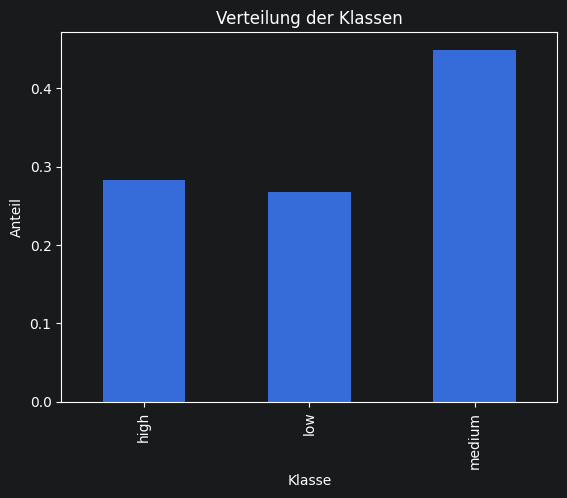

In [1201]:
import matplotlib.pyplot as plt

classification_full["emotion_structure_v3"] \
    .value_counts(normalize=True) \
    .sort_index() \
    .plot(kind="bar")

plt.ylabel("Anteil")
plt.xlabel("Klasse")
plt.title("Verteilung der Klassen")
plt.show()

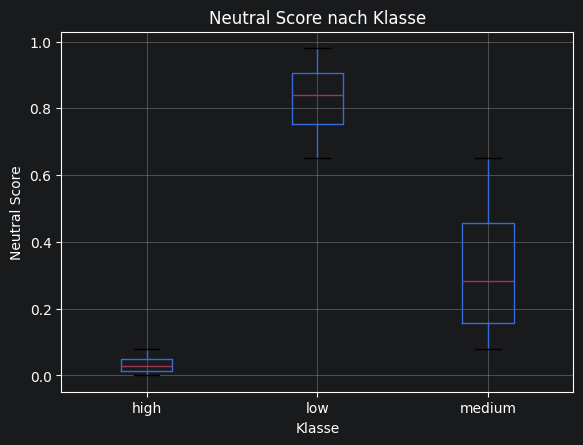

In [1202]:
classification_full.boxplot(
    column="neutral",
    by="emotion_structure_v3"
)

plt.title("Neutral Score nach Klasse")
plt.suptitle("")
plt.xlabel("Klasse")
plt.ylabel("Neutral Score")
plt.show()